In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sqlalchemy import create_engine

plt.rcParams["figure.figsize"] = (12,6)

In [3]:
fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_calendar.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/05_category_inflows.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [4]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

In [5]:
top5 = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(5)["amfi_code"]
)

In [6]:
print(nav_history["date"].dtype)

datetime64[us]


In [7]:
print("AUM")
print(aum.columns.tolist())

print("\nSIP")
print(sip.columns.tolist())

print("\nCATEGORY")
print(category.columns.tolist())

print("\nHOLDINGS")
print(holdings.columns.tolist())

print("\nFOLIO")
print(folio.columns.tolist())

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

CATEGORY
['month', 'category', 'net_inflow_crore']

HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

FOLIO
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


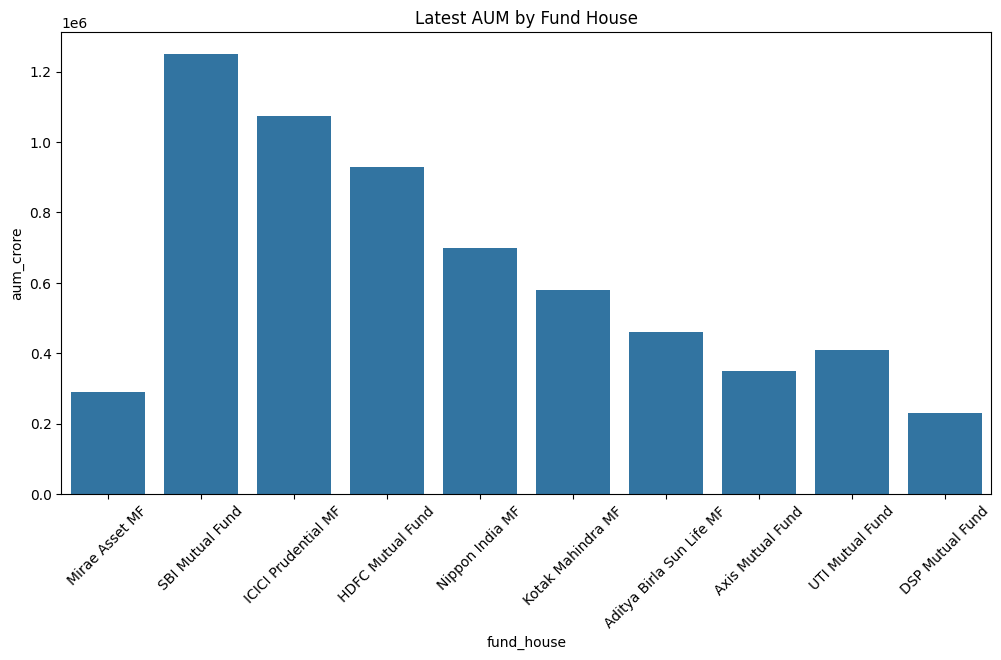

In [8]:
latest_aum = (
    aum.sort_values("date")
       .groupby("fund_house")
       .tail(1)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=latest_aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=45)
plt.title("Latest AUM by Fund House")
plt.show()

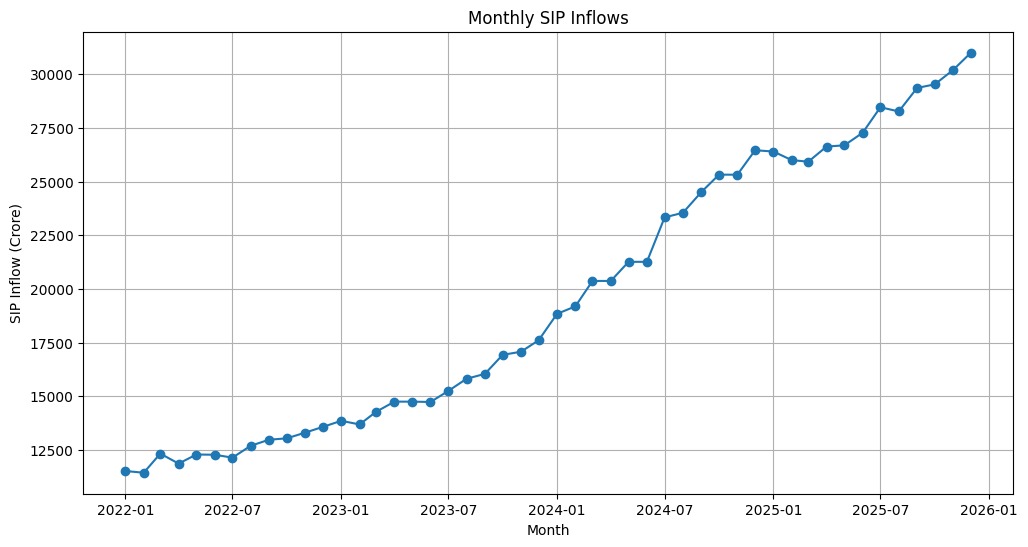

In [9]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

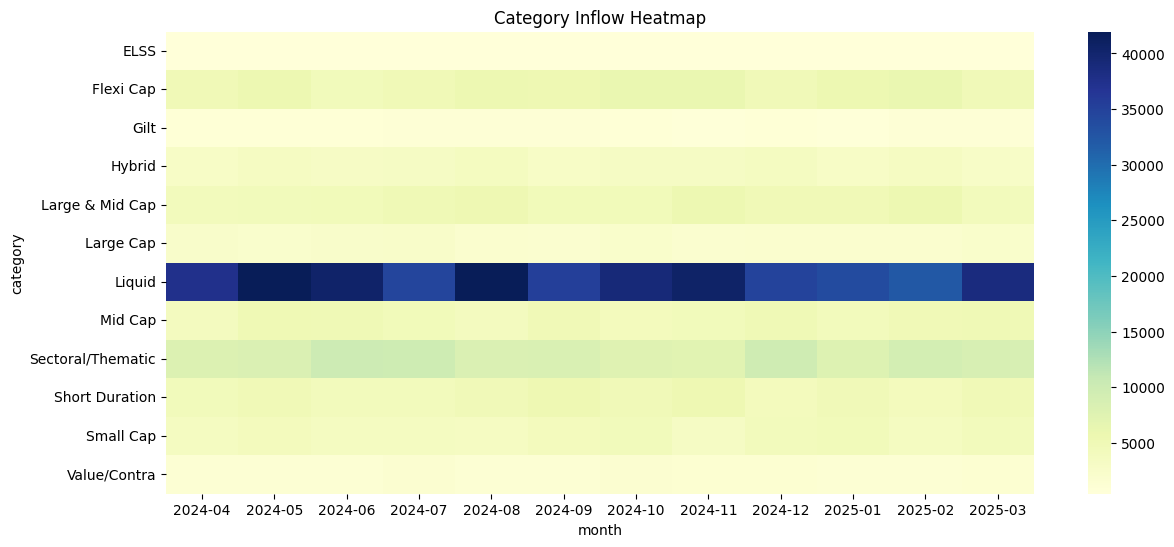

In [10]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.show()

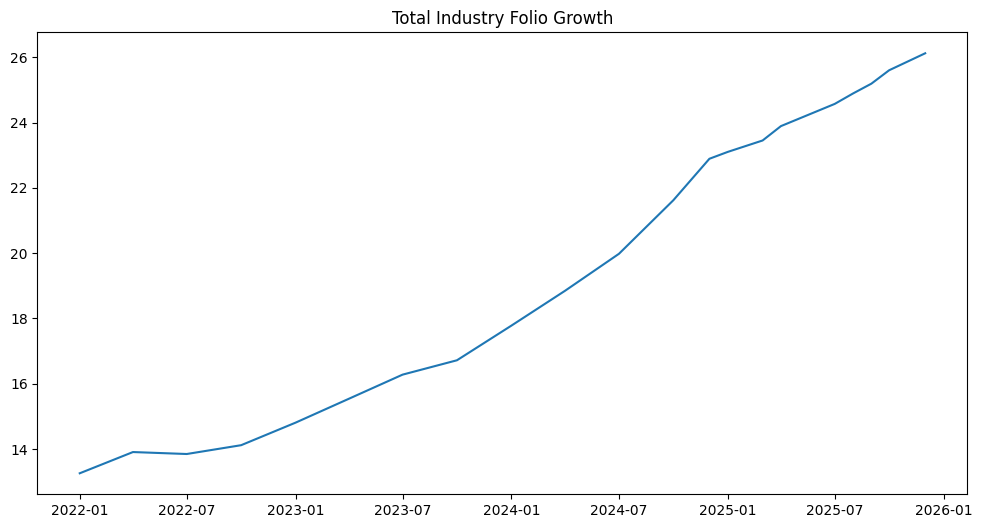

In [11]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Total Industry Folio Growth")
plt.show()

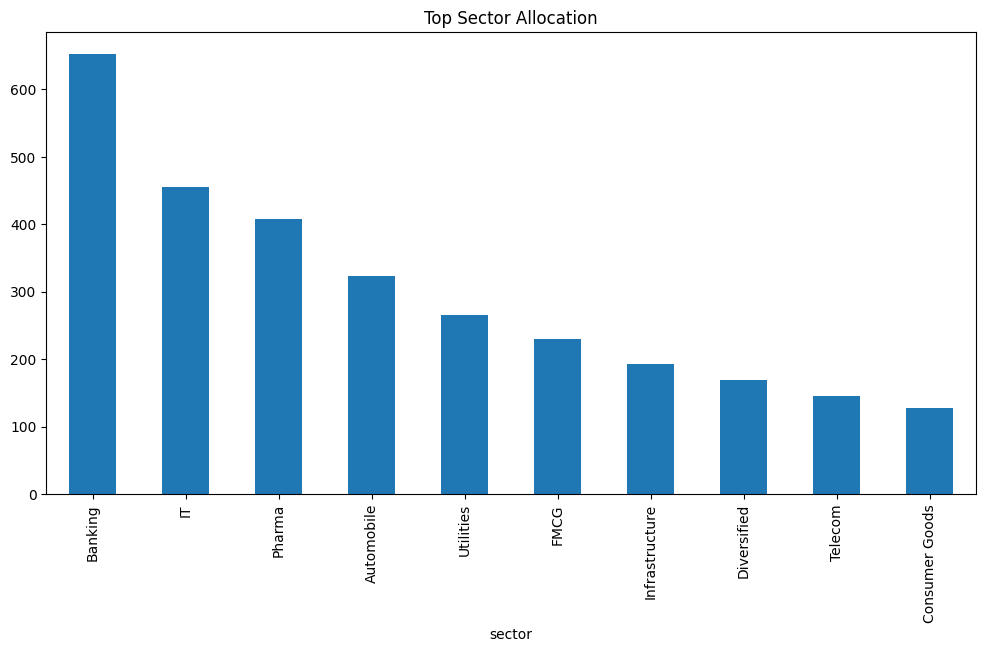

In [12]:
sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sector_alloc.plot(
    kind="bar"
)

plt.title("Top Sector Allocation")
plt.show()

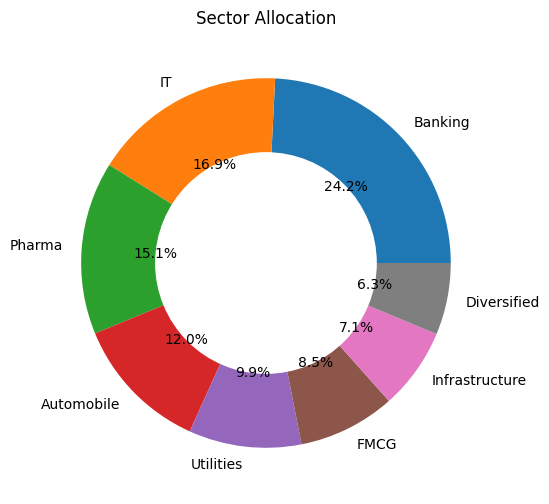

In [13]:
top_sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

plt.pie(
    top_sector,
    labels=top_sector.index,
    autopct="%1.1f%%"
)

centre = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre)

plt.title("Sector Allocation")
plt.show()

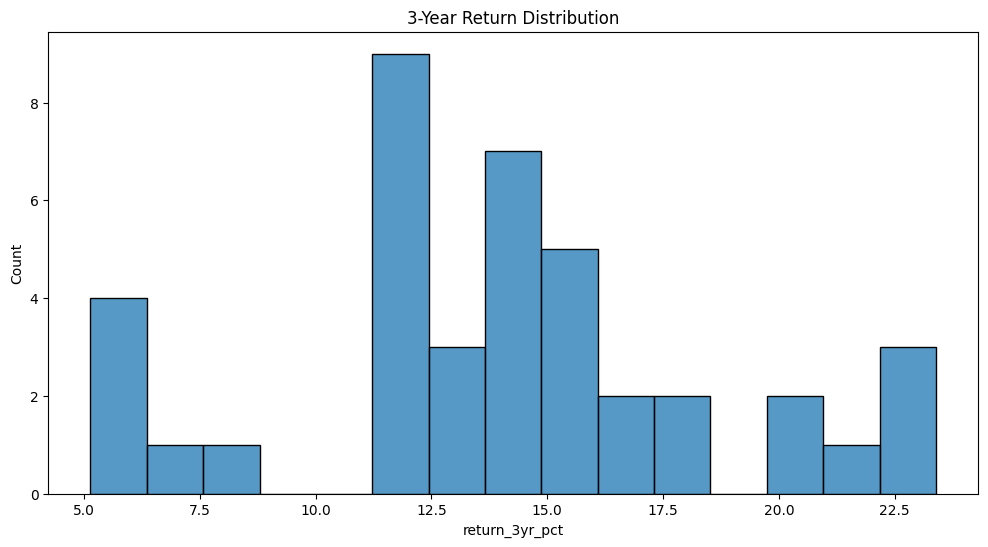

In [14]:
sns.histplot(
    performance["return_3yr_pct"],
    bins=15
)

plt.title("3-Year Return Distribution")
plt.show()

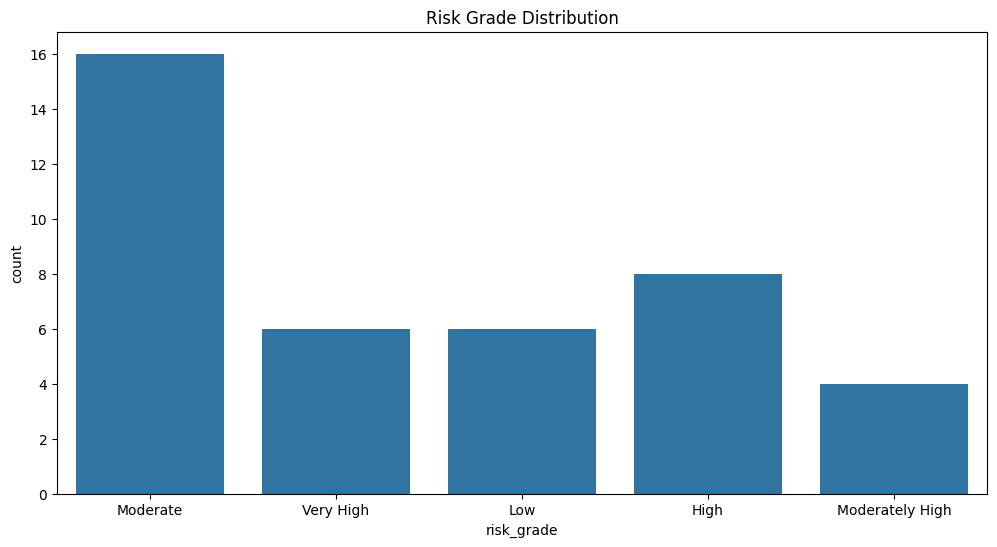

In [15]:
sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")
plt.show()

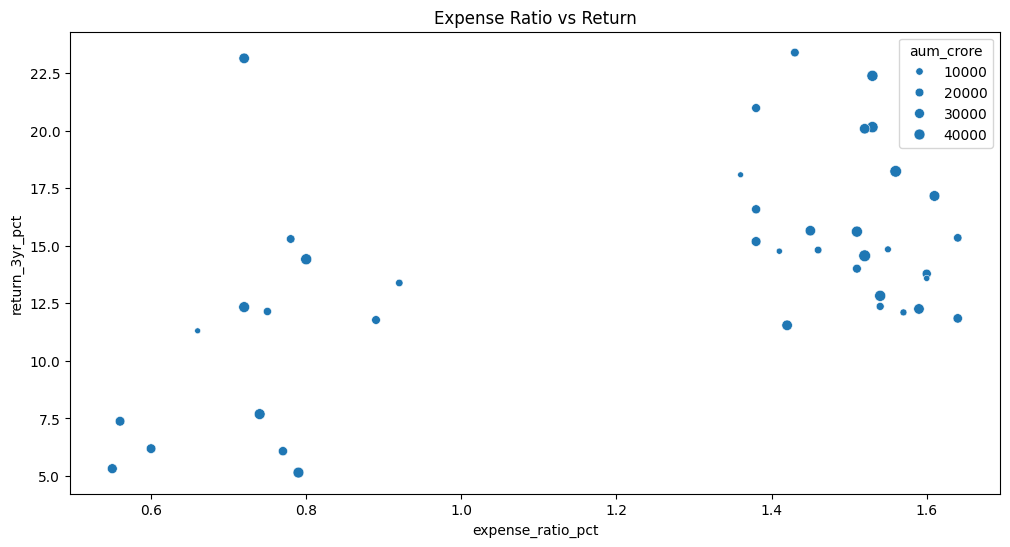

In [16]:
sns.scatterplot(
    data=performance,
    x="expense_ratio_pct",
    y="return_3yr_pct",
    size="aum_crore"
)

plt.title("Expense Ratio vs Return")
plt.show()

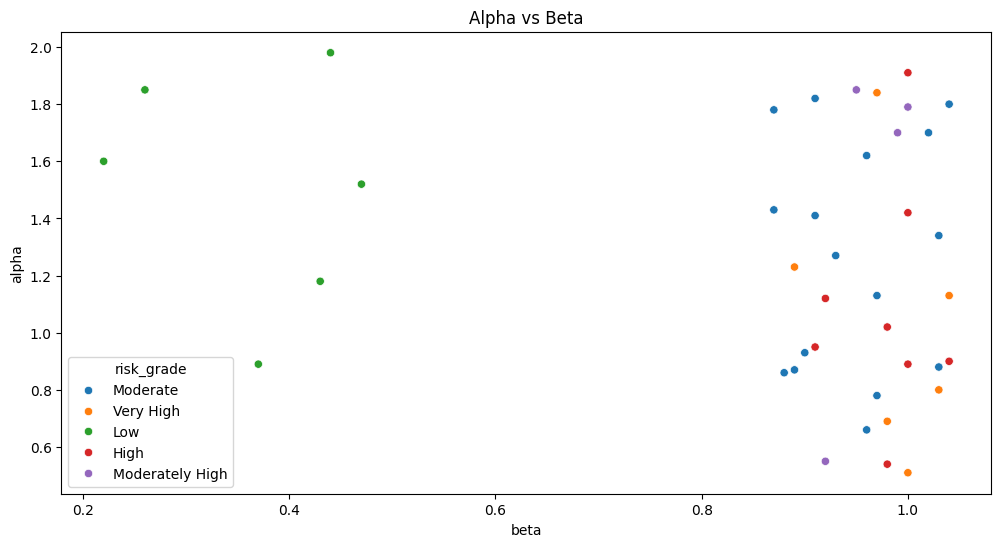

In [17]:
sns.scatterplot(
    data=performance,
    x="beta",
    y="alpha",
    hue="risk_grade"
)

plt.title("Alpha vs Beta")
plt.show()

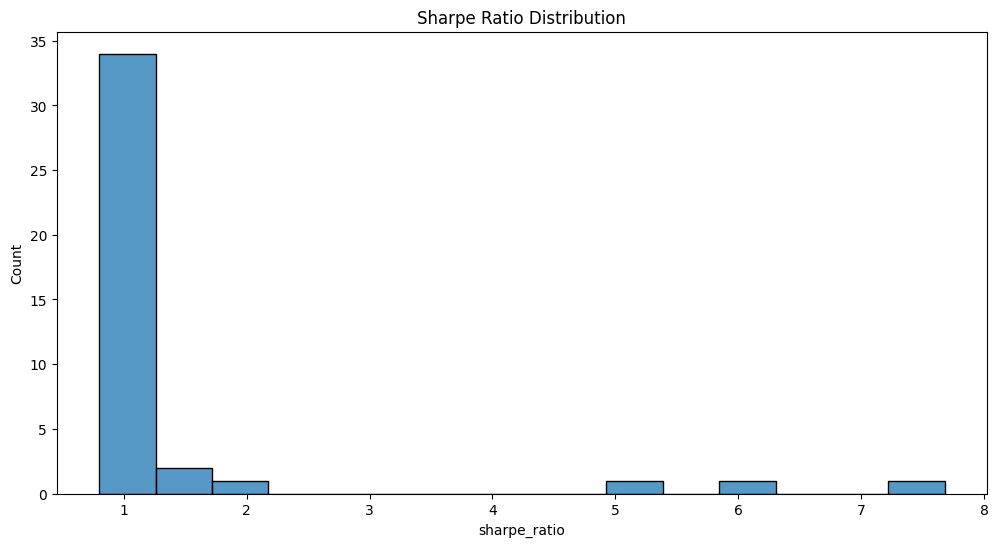

In [18]:
sns.histplot(
    performance["sharpe_ratio"],
    bins=15
)

plt.title("Sharpe Ratio Distribution")
plt.show()

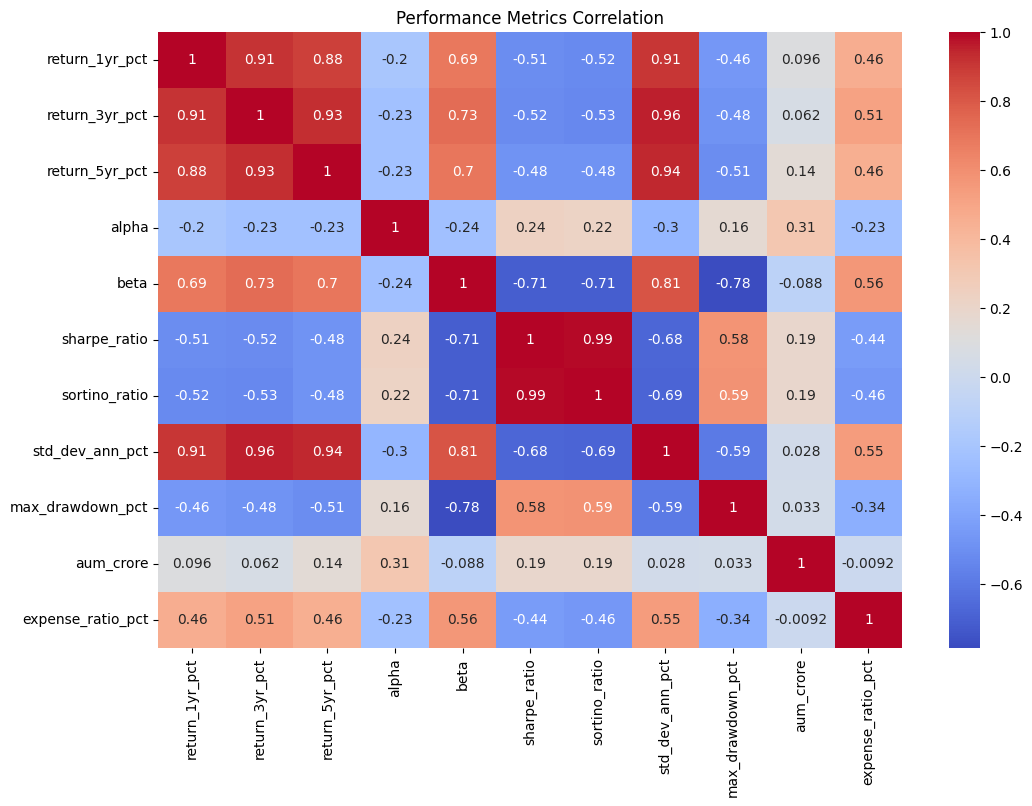

In [19]:
cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "sortino_ratio",
    "std_dev_ann_pct",
    "max_drawdown_pct",
    "aum_crore",
    "expense_ratio_pct"
]

plt.figure(figsize=(12,8))

sns.heatmap(
    performance[cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Performance Metrics Correlation")
plt.show()

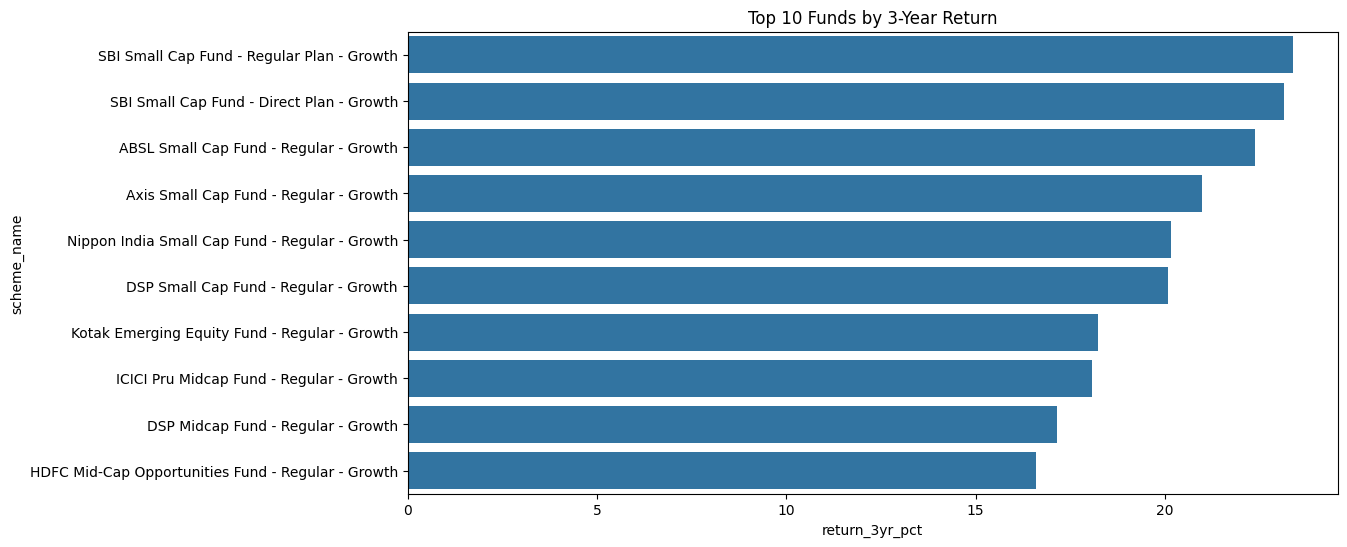

In [20]:
top_returns = (
    performance
    .sort_values(
        "return_3yr_pct",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top_returns,
    x="return_3yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 3-Year Return")
plt.show()

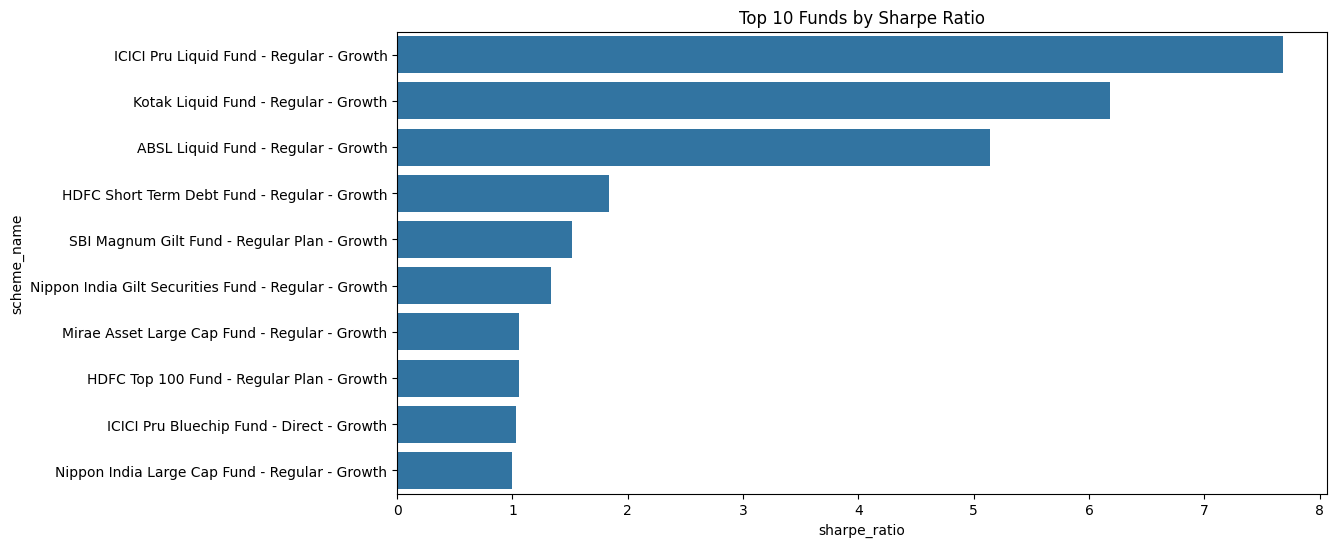

In [21]:
top_sharpe = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.show()

In [22]:
largest_house = latest_aum.loc[
    latest_aum["aum_crore"].idxmax(),
    "fund_house"
]

best_return = performance.loc[
    performance["return_3yr_pct"].idxmax(),
    "scheme_name"
]

best_sharpe = performance.loc[
    performance["sharpe_ratio"].idxmax(),
    "scheme_name"
]

top_age = transactions["age_group"].mode()[0]

top_transaction = transactions["transaction_type"].mode()[0]

top_state = transactions["state"].mode()[0]

top_risk = performance["risk_grade"].mode()[0]

top_sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .idxmax()
)

print("Largest Fund House:", largest_house)
print("Highest 3-Year Return Fund:", best_return)
print("Highest Sharpe Ratio Fund:", best_sharpe)
print("Most Common Age Group:", top_age)
print("Most Common Transaction Type:", top_transaction)
print("Top State:", top_state)
print("Most Common Risk Grade:", top_risk)
print("Top Sector:", top_sector)

Largest Fund House: SBI Mutual Fund
Highest 3-Year Return Fund: SBI Small Cap Fund - Regular Plan - Growth
Highest Sharpe Ratio Fund: ICICI Pru Liquid Fund - Regular - Growth
Most Common Age Group: 26-35
Most Common Transaction Type: SIP
Top State: Punjab
Most Common Risk Grade: Moderate
Top Sector: Banking


In [23]:
transactions.to_csv(
    "../data/processed/investor_analytics.csv",
    index=False
)

In [24]:
sip.to_csv(
    "../data/processed/sip_trends.csv",
    index=False
)

In [25]:
category.to_csv(
    "../data/processed/05_category_inflows.csv",
    index=False
)

In [26]:
import pandas as pd

scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

scorecard.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'return_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'max_drawdown_pct',
 'expense_ratio_pct',
 'risk_grade',
 'return_rank',
 'sharpe_rank',
 'alpha_rank',
 'expense_rank',
 'beta_rank',
 'drawdown_rank',
 'fund_score']